In [1]:
from baselines.Custom import mappo_rnn_mpe
from baselines.Custom.simple_spread_visualizer import MPEVisualizer
import importlib.resources as resources
import yaml
from omegaconf import OmegaConf
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Playground.ipynb"
import jaxmarl
from jaxmarl.environments.mpe.simple_spread import SimpleSpreadMPE
from jaxmarl.wrappers.baselines import MPELogWrapper



In [2]:
import jax
import jaxlib
import flax

print(jax.devices())
print("JAX version:", jax.__version__)
print("JAXlib version:", jaxlib.__version__)
print("Flax version:", flax.__version__)


[CudaDevice(id=0)]
JAX version: 0.4.38
JAXlib version: 0.4.38
Flax version: 0.10.1


In [3]:
algo_and_config_map = {
    "mappo_rnn_mpe": (mappo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "mappo_rnn_mpe_simple_spread.yaml"))
}

In [4]:
%%time
ALGO_NAME = "mappo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]

CPU times: user 6 μs, sys: 3 μs, total: 9 μs
Wall time: 16.5 μs


In [ ]:

config['TOTAL_TIMESTEPS'] = 100000
config["ENV_KWARGS"] = {}

In [6]:
config

{'LR': 0.002, 'NUM_ENVS': 16, 'NUM_STEPS': 128, 'TOTAL_TIMESTEPS': 5000, 'FC_DIM_SIZE': 128, 'GRU_HIDDEN_DIM': 128, 'UPDATE_EPOCHS': 4, 'NUM_MINIBATCHES': 4, 'GAMMA': 0.99, 'GAE_LAMBDA': 0.95, 'CLIP_EPS': 0.2, 'SCALE_CLIP_EPS': False, 'ENT_COEF': 0.01, 'VF_COEF': 0.5, 'MAX_GRAD_NORM': 0.5, 'ACTIVATION': 'tanh', 'ENV_NAME': 'MPE_simple_spread_v3', 'SEED': 1, 'NUM_SEEDS': 2, 'ENV_KWARGS': {}, 'ANNEAL_LR': True, 'ENTITY': 'emiecz-princeton', 'PROJECT': 'ScalingLaws', 'WANDB_MODE': 'offline', 'RUN_NAME': 'mappo-rnn-simple-spread_5_landmarks_5_agents'}

In [1]:
import time
for num_agents in range(3,4):
    for num_landmarks in range(3,4):
        start = time.time()
        config["ENV_KWARGS"]["num_agents"] = num_agents
        config["ENV_KWARGS"]["num_landmarks"] = num_landmarks
        config['RUN_NAME'] = f"mappo-rnn-simple-spread_{num_landmarks}_landmarks_{num_agents}_agents" 
        
        print(f"Running MPE Training with run name {config['RUN_NAME']}, and config {config['ENV_KWARGS']}")
        out = algo.main(config)
        print(f"Finished in {time.time()-start}")

NameError: name 'config' is not defined

## Training Multiple Configurations

**WandB Configuration Notes:**
- The `main()` function now automatically saves `num_agents` and `num_landmarks` to wandb config and summary
- `requirements.txt` is saved automatically by wandb (not in code)
- Each run properly closes with `wandb.finish()` to allow multiple sequential runs
- `reinit=True` allows running multiple experiments in the same notebook session

**To retrieve configuration later:**
```python
# Check the wandb run config or summary to see num_agents and num_landmarks
run = wandb.Api().run("entity/project/run_id")
num_agents = run.config["num_agents"]
num_landmarks = run.config["num_landmarks"]
```

In [9]:
def load_params_offline(path="wandb/offline-run-20251008_121315-shellov1/files"):
    """Load Flax parameters from a local W&B offline run folder."""
    with open(f"{path}/final_actor_params.msgpack", "rb") as f:
        actor_params = flax.serialization.from_bytes(None, f.read())
    with open(f"{path}/final_critic_params.msgpack", "rb") as f:
        critic_params = flax.serialization.from_bytes(None, f.read()) 

    return actor_params, critic_params
actor_params, critic_params = load_params_offline(
    path="wandb/offline-run-20251029_190906-1kwi3kii/files"
)

In [ ]:
def load_params_from_wandb(run_path):
    """Load Flax parameters from a W&B run given its path."""
    import wandb
    import flax

    api = wandb.Api()
    run = api.run(run_path)

    # Load actor parameters
    actor_artifact = run.use_artifact('final_actor_params:latest')
    actor_dir = actor_artifact.download()
    with open(f"{actor_dir}/final_actor_params.msgpack", "rb") as f:
        actor_params = flax.serialization.from_bytes(None, f.read())

    # Load critic parameters
    critic_artifact = run.use_artifact('final_critic_params:latest')
    critic_dir = critic_artifact.download()
    with open(f"{critic_dir}/final_critic_params.msgpack", "rb") as f:
        critic_params = flax.serialization.from_bytes(None, f.read())

    # Load metadata
    config_artifact = run.use_artifact('config:latest')
    config_dir = config_artifact.download()
    with open(f"{config_dir}/config.yaml", "r") as f:
        metadata = yaml.safe_load(f)

    return actor_params, critic_params, metadata

run_path = "dbraga/mappo-rnn-simple-spread_3_landmarks_3_agents/1kwi3kii"

In [22]:
from baselines.Custom.mappo_rnn_mpe import ScannedRNN, ActorRNN, CriticRNN, MPEWorldStateWrapper

import jax.numpy as jnp

# Use actor_params and critic_params loaded above
params = actor_params  # for actor network
critic_p = critic_params  # for critic network

# Prepare environment and batch - MAPPO needs both wrappers!
data = {"ENV_KWARGS": {"num_landmarks": 3, "num_agents": 3}}
config['NUM_ENVS'] = 1
base_env = jaxmarl.make(config["ENV_NAME"], max_steps=50, **data['ENV_KWARGS'])
env = MPEWorldStateWrapper(base_env)  # Adds world_state to observations
env = MPELogWrapper(env)  # Adds episode tracking
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config["NUM_ENVS"])
obs, env_state = jax.vmap(env.reset, in_axes=(0,))(rngs)
num_actors = env.num_agents * config["NUM_ENVS"]

# Prepare initial hidden states for RNNs - use num_actors as batch size, not NUM_ENVS
ac_init_hstate = ScannedRNN.initialize_carry(num_actors, config["GRU_HIDDEN_DIM"])
cr_init_hstate = ScannedRNN.initialize_carry(num_actors, config["GRU_HIDDEN_DIM"])

# Prepare input for actor and critic
obs_batch = jnp.stack([obs[a] for a in env.agents])  # (num_agents, obs_dim)
obs_batch = obs_batch.reshape(1, num_actors, -1)     # (batch=1, num_actors, obs_dim)
done_batch = jnp.zeros((1, num_actors))              # (batch=1, num_actors)


In [23]:
# Actor step
actor_net = ActorRNN(env.action_space(env.agents[0]).n, config=config)
# Add time dimension for the RNN scan - use [None, :] to add dimension at the front
ac_in = (obs_batch[0][None, :], done_batch[0][None, :])
ac_hstate, pi = actor_net.apply(params, ac_init_hstate, ac_in)
rng, _rng = jax.random.split(rng)
actions = pi.sample(seed=_rng)
log_prob = pi.log_prob(actions)


In [24]:
# Critic step
# For MAPPO, use the world_state from the wrapped environment
# The MPEWorldStateWrapper provides this automatically
world_state = obs["world_state"]  # (num_envs, num_agents, world_state_size)
# Reshape to (num_actors, world_state_size)
world_state = world_state.transpose(1, 0, 2).reshape(-1, world_state.shape[-1])

critic_net = CriticRNN(config=config)
# Add time dimension for both world_state and done_batch
dones = jnp.zeros((num_actors,), dtype=jnp.float32)
cr_hstate, value = critic_net.apply(critic_p, cr_init_hstate, (world_state[None, :], dones[None, :]))

print("Actions:", actions)
print("Log prob:", log_prob)
print("Value:", value)


Actions: [[0 2 3]]
Log prob: [[-1.6549584 -1.5283407 -1.5557181]]
Value: [[-0.99666893 -0.99666893 -0.99666893]]


In [25]:
%%time
import jax.numpy as jnp
import numpy as np

# Prepare environment with both wrappers for MAPPO
config['NUM_ENVS'] = 1
base_env = jaxmarl.make(config["ENV_NAME"], max_steps=50, **data['ENV_KWARGS'])
env = MPEWorldStateWrapper(base_env)  # Adds world_state to observations
env = MPELogWrapper(env)  # Adds episode tracking
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config["NUM_ENVS"])
obs, env_state = jax.vmap(env.reset, in_axes=(0,))(rngs)

# Use MAPPO RNN actor network
actor_net = ActorRNN(env.action_space(env.agents[0]).n, config=config)
num_actors = env.num_agents * config["NUM_ENVS"]
# Initialize hidden state for actor
ac_hstate = ScannedRNN.initialize_carry(num_actors, config["GRU_HIDDEN_DIM"])

state_seq = [env_state.env_state]

for _ in range(100):
        # Batchify obs for actor RNN: (num_actors, obs_dim)
        obs_batch = jnp.stack([obs[a] for a in env.agents])
        obs_batch = obs_batch.transpose(1, 0, 2).reshape(-1, obs_batch.shape[-1])
        dones = jnp.zeros((num_actors,), dtype=jnp.float32)
        # Add time dimension for scan
        ac_in = (obs_batch[None, :, :], dones[None, :])

        # Get actions from actor
        ac_hstate, pi = actor_net.apply(actor_params, ac_hstate, ac_in)

        # Sample actions
        rng, _rng = jax.random.split(rng)
        actions = pi.sample(seed=_rng)

        # unbatch actions for environment
        actions = actions.reshape(config["NUM_ENVS"], env.num_agents)
        act_dict = {a: np.array(actions[:, i]) for i, a in enumerate(env.agents)}

        # Step environment
        rng_step = jax.random.split(_rng, config["NUM_ENVS"])
        obs, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0, 0, 0))(
            rng_step, env_state, act_dict
        )
        
        state_seq.append(env_state.env_state)

print(f"Collected {len(state_seq)} states for visualization")


Collected 101 states for visualization
CPU times: user 1min, sys: 5.06 s, total: 1min 5s
Wall time: 1min


Comm active?  False


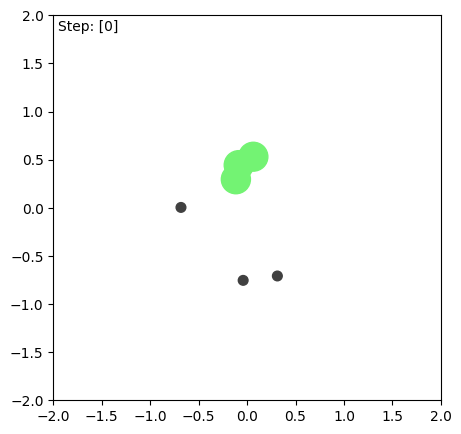

In [ ]:
from baselines.Custom.simple_spread_visualizer import MPEVisualizer
env_spread = jaxmarl.make("MPE_simple_spread_v3", **data["ENV_KWARGS"])
viz = MPEVisualizer(env_spread, state_seq)
viz.animate()